# AM-Peak Trip Generation Rates per Person — by TAZ and Superzone

Assesses trips generated per person between 6:00 and 9:00 from the survey, using the `wf_new` household expansion weights on both sides of the ratio:

- **Numerator** — expanded AM-peak trips (same extraction rule as all matrices) made by a zone's *residents*, attributed to the household's home `TAZ` / `SuperZone` from `households_with_weights.csv`, regardless of where the trip takes place.
- **Denominator** — expanded population: surveyed persons per household (distinct `INDIVID` in the activity diary) × `wf_new`, summed by home zone.

This is a trip *production* rate by residence zone (the classic trip-generation quantity), computed per survey day and averaged.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, ORANGE = '#2a78d6', '#eb6834'
INK, INK2 = '#0b0b0b', '#52514e'

In [2]:
df = pd.read_csv('Input/Matrices/ACTIVITIES_DEC18_corrected.csv')
hh = pd.read_csv('Input/Matrices/households_with_weights.csv')  # HHID, TAZ, SuperZone, wf, wf_new

# expanded population by home zone
persons = df.groupby('HHID')['INDIVID'].nunique().rename('n_persons')
hh = hh.set_index('HHID').join(persons)
assert hh['n_persons'].notna().all()
hh['w_persons'] = hh['wf_new'] * hh['n_persons']
print(f"surveyed persons: {hh['n_persons'].sum():,.0f} in {len(hh):,} households "
      f"(mean {hh['n_persons'].mean():.2f}/household)")
print(f"expanded population: {hh['w_persons'].sum():,.0f}")

surveyed persons: 16,401 in 5,108 households (mean 3.21/household)
expanded population: 2,682,356


In [3]:
def am_peak_trips(df_day):
    d = df_day.sort_values(by=['INDIVID', 'tourID', 'ACT_ID'])
    d['origin'] = d.groupby(['INDIVID', 'tourID'])['taz'].shift(1)
    d['destination'] = d['taz']
    d['StartTime'] = pd.to_datetime(d['StartTime'], dayfirst=True)
    d['EndTime'] = pd.to_datetime(d['EndTime'], dayfirst=True)
    d['leaving_time'] = pd.to_datetime(np.where(d['mainActivity'] == 'Home', d['EndTime'], d['StartTime']))
    mask = (d['leaving_time'].dt.hour >= 6) & (d['leaving_time'].dt.hour < 9)
    return d[mask].dropna(subset=['origin', 'destination'])

# trips per household per day (all AM-peak trips, wherever they occur)
trip_counts = {}
for day in (10, 20):
    t = am_peak_trips(df[df['ACT_DAY'] == day].copy())
    trip_counts[day] = t.groupby('HHID').size().rename(f'trips_{day}')

hh = hh.join(trip_counts[10]).join(trip_counts[20]).fillna({'trips_10': 0, 'trips_20': 0})
hh['w_trips_10'] = hh['wf_new'] * hh['trips_10']
hh['w_trips_20'] = hh['wf_new'] * hh['trips_20']

overall_10 = hh['w_trips_10'].sum() / hh['w_persons'].sum()
overall_20 = hh['w_trips_20'].sum() / hh['w_persons'].sum()
print(f"overall AM-peak trips per person:  day 10 = {overall_10:.3f},  day 20 = {overall_20:.3f},  "
      f"avg = {(overall_10 + overall_20) / 2:.3f}")

overall AM-peak trips per person:  day 10 = 0.856,  day 20 = 0.844,  avg = 0.850


In [4]:
def rates_by(group_col):
    g = hh.groupby(group_col).agg(
        households=('n_persons', 'size'),
        sampled_persons=('n_persons', 'sum'),
        weighted_persons=('w_persons', 'sum'),
        weighted_trips_10=('w_trips_10', 'sum'),
        weighted_trips_20=('w_trips_20', 'sum'),
    )
    g['rate_10'] = g['weighted_trips_10'] / g['weighted_persons']
    g['rate_20'] = g['weighted_trips_20'] / g['weighted_persons']
    g['rate_avg'] = (g['rate_10'] + g['rate_20']) / 2
    return g

taz_rates = rates_by('TAZ')
sz_rates = rates_by('SuperZone')

taz_rates.to_csv('Output/trip_generation_taz.csv', float_format='%.6g')
sz_rates.to_csv('Output/trip_generation_sz.csv', float_format='%.6g')
print(f"TAZ table: {len(taz_rates)} home zones | superzone table: {len(sz_rates)} zones")
print("saved: Output/trip_generation_taz.csv, Output/trip_generation_sz.csv")
sz_rates.round(3)

TAZ table: 511 home zones | superzone table: 35 zones
saved: Output/trip_generation_taz.csv, Output/trip_generation_sz.csv


,households,sampled_persons,weighted_persons,weighted_trips_10,weighted_trips_20,rate_10,rate_20,rate_avg
SuperZone,,,,,,,,
1,217,626,92887.282,84523.102,86742.186,0.910,0.934,0.922
2,233,749,133288.711,102251.398,96209.339,0.767,0.722,0.744
3,238,948,151581.764,117605.386,116152.547,0.776,0.766,0.771
4,266,1047,122288.258,73847.305,77468.259,0.604,0.633,0.619
5,118,269,41890.068,32484.997,32738.410,0.775,0.782,0.779
6,118,275,44520.417,42337.127,42438.065,0.951,0.953,0.952
7,123,303,44654.153,42147.584,38263.815,0.944,0.857,0.900
8,133,363,37795.687,33697.149,34186.329,0.892,0.905,0.898
9,132,372,62395.102,66456.343,67260.319,1.065,1.078,1.072


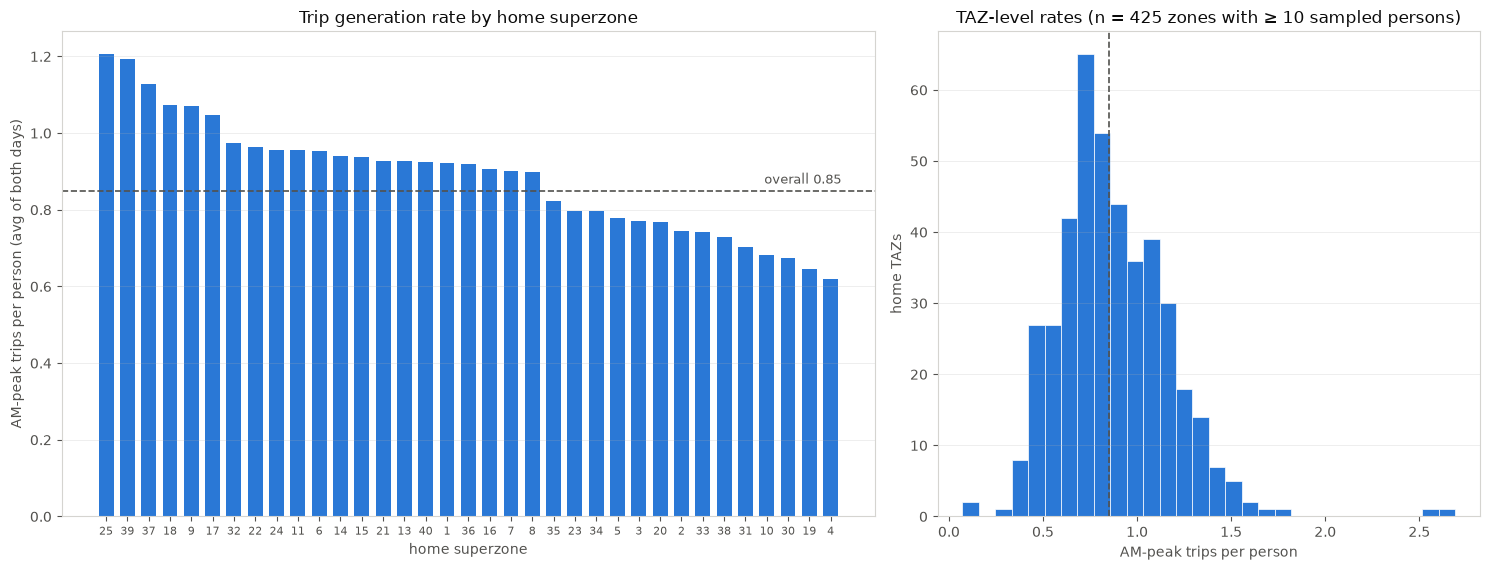

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8), facecolor='white', gridspec_kw={'width_ratios': [1.5, 1]})

# superzone rates, sorted
s = sz_rates.sort_values('rate_avg', ascending=False)
overall = (overall_10 + overall_20) / 2
ax = axes[0]
ax.bar(range(len(s)), s['rate_avg'], color=BLUE, width=0.7)
ax.axhline(overall, color=INK2, linestyle='--', linewidth=1.2)
ax.annotate(f'overall {overall:.2f}', xy=(len(s) - 0.5, overall), xytext=(0, 5),
            textcoords='offset points', color=INK2, fontsize=9, ha='right')
ax.set_xticks(range(len(s)))
ax.set_xticklabels([f'{int(z)}' for z in s.index], fontsize=8)
ax.set_xlabel('home superzone', color=INK2)
ax.set_ylabel('AM-peak trips per person (avg of both days)', color=INK2)
ax.set_title('Trip generation rate by home superzone', color=INK, fontsize=12)
ax.grid(True, axis='y', alpha=0.25, linewidth=0.6)
for sp in ax.spines.values(): sp.set_color('#d5d4d0')
ax.tick_params(colors=INK2)

# TAZ rate distribution (reliable zones only)
ax = axes[1]
reliable = taz_rates[taz_rates['sampled_persons'] >= 10]
ax.hist(reliable['rate_avg'], bins=30, color=BLUE, edgecolor='white', linewidth=0.5)
ax.axvline(overall, color=INK2, linestyle='--', linewidth=1.2)
ax.set_xlabel('AM-peak trips per person', color=INK2)
ax.set_ylabel('home TAZs', color=INK2)
ax.set_title(f'TAZ-level rates (n = {len(reliable)} zones with ≥ 10 sampled persons)', color=INK, fontsize=12)
ax.grid(True, axis='y', alpha=0.25, linewidth=0.6)
for sp in ax.spines.values(): sp.set_color('#d5d4d0')
ax.tick_params(colors=INK2)

plt.tight_layout()
plt.savefig('Output/figures/trip_generation_rates.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
print("superzone rates — highest and lowest (avg of both days):")
s = sz_rates.sort_values('rate_avg', ascending=False)
display_cols = ['sampled_persons', 'weighted_persons', 'rate_10', 'rate_20', 'rate_avg']
print(s[display_cols].head(5).round(3).to_string())
print("...")
print(s[display_cols].tail(5).round(3).to_string())

low_n = taz_rates[taz_rates['sampled_persons'] < 10]
print(f"\nTAZ reliability: {len(low_n)} of {len(taz_rates)} home TAZs have < 10 sampled persons — "
      "treat their rates as indicative only (flagged by the sampled_persons column).")

superzone rates — highest and lowest (avg of both days):
           sampled_persons  weighted_persons  rate_10  rate_20  rate_avg
SuperZone                                                               
25                      90         26626.511    1.142    1.269     1.205
39                     335        110067.249    1.229    1.157     1.193
37                     142         31964.650    1.142    1.116     1.129
18                     165         24658.658    1.177    0.969     1.073
9                      372         62395.102    1.065    1.078     1.072
...
           sampled_persons  weighted_persons  rate_10  rate_20  rate_avg
SuperZone                                                               
31                     246         55679.200    0.727    0.680     0.703
10                     419         35507.743    0.701    0.660     0.681
30                     347         71715.933    0.671    0.679     0.675
19                     736        230349.824    0.618    0.673 

## Notes

- Trips are attributed to the household's **home zone** (residence), not the trip's origin zone — this is a production rate, the quantity a trip-generation model estimates. The home `TAZ` / `SuperZone` come from `households_with_weights.csv` (verified consistent with the keys table's `SZ_NEW`).
- The denominator counts *surveyed* persons (individuals with diary records) expanded by `wf_new`. If the survey skipped household members (e.g. children under the survey age), rates are per surveyed-age person, not per capita of the full population.
- All AM-peak trips count, including trips outside the 778-TAZ system — totals here are therefore slightly higher than the matrix totals restricted to it.
- Zones never sampled as home locations (267 of the 778 TAZs) have no rate — that is missing data, not a zero rate.